<h1>Learning with <b>selected</b> data</h1>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

FEATURES = ["RR_l_0", "RR_l_0/RR_l_1", "RR_r_0", "R_val", "P_val", "signal_std"]

# 1) Load your existing 80% learning data
learn_df = pd.read_csv("original_selected_features_data/learn_valid_80.csv")

# 2) Split into train/validation
X_learn = learn_df[FEATURES]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)

# 3) Train Random Forest on the training portion
rf_selected_features = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_selected_features.fit(X_train, y_train)

# 4) Validate
y_pred = rf_selected_features.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

In [ ]:
test_df = pd.read_csv("original_selected_features_data/test_20.csv")

X_test, y_test = test_df[FEATURES], test_df["label"]

# Evaluate on the 20% test set
y_pred = rf_selected_features.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

<h1>Learning with <b>tsne</b> data</h1>

In [ ]:
# 1) Load your existing 80% learning data
learn_df = pd.read_csv("tsne_data/learn_valid_80.csv")

# 2) Split into train/validation
X_learn = learn_df[["tsne_x", "tsne_y"]]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)

# 3) Train Random Forest on the training portion
rf_tsne = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_tsne.fit(X_train, y_train)

# 4) Validate
y_pred = rf_tsne.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

In [ ]:
test_df = pd.read_csv("tsne_data/test_20.csv")

X_test, y_test = test_df[["tsne_x", "tsne_y"]], test_df["label"]

# Evaluate on the 20% test set
y_pred = rf_tsne.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

<h1>Learning with <b>all</b> data</h1>

In [ ]:
learn_df = pd.read_csv("original_all_features_data/learn_valid_80.csv")

# keep only numeric columns
numeric_cols = learn_df.select_dtypes(include=[np.number]).columns

# features = all numeric columns except label (in case label is numeric)
feature_cols = numeric_cols.drop("label") if "label" in numeric_cols else numeric_cols

X_learn = learn_df[feature_cols]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)

# 3) Train Random Forest on the training portion
rf_all_features = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_all_features.fit(X_train, y_train)

# 4) Validate
y_pred = rf_all_features.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

In [ ]:
test_df = pd.read_csv("original_all_features_data/test_20.csv")

X_test, y_test = test_df[feature_cols], test_df["label"]

# Evaluate on the 20% test set
y_pred = rf_all_features.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

<h1>Optimizing <b>all</b> data set</h1>

In [ ]:
# Grid search for Random Forest hyperparameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate best model on validation set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_valid)
print(f"\nValidation accuracy: {accuracy_score(y_valid, y_pred):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

In [ ]:
# Feature importance visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print top 10 features
print("\nTop 10 most important features:")
for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_cols[indices[i]]}: {importances[indices[i]]:.4f}")

<h1>Visualization of Decision Boundaries (t-SNE data only)</h1>

In [ ]:
# Note: This visualization only works with t-SNE data (2D)
# We need to reload the t-SNE dataset and retrain for visualization

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Reload t-SNE data
learn_df_tsne = pd.read_csv("tsne_data/learn_valid_80.csv")
X_learn_tsne = learn_df_tsne[["tsne_x", "tsne_y"]]
y_learn_tsne = learn_df_tsne["label"]

X_train_tsne, X_valid_tsne, y_train_tsne, y_valid_tsne = train_test_split(
    X_learn_tsne, y_learn_tsne, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn_tsne
)

# Train RF for visualization
rf_viz = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_viz.fit(X_train_tsne, y_train_tsne)

# Prepare grid
X_all_tsne = pd.concat([X_train_tsne, X_valid_tsne], axis=0)
pad = 1.0
x_min = X_all_tsne["tsne_x"].quantile(0.01) - pad
x_max = X_all_tsne["tsne_x"].quantile(0.99) + pad
y_min = X_all_tsne["tsne_y"].quantile(0.01) - pad
y_max = X_all_tsne["tsne_y"].quantile(0.99) + pad

h = 0.25
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = rf_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
bg_cmap = ListedColormap(["#f46d43", "#66bd63"])

plt.figure(figsize=(8, 5))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

classes = np.unique(pd.concat([y_train_tsne, y_valid_tsne]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

# Plot validation points
for cls in classes:
    m = y_valid_tsne == cls
    plt.scatter(X_valid_tsne.loc[m, "tsne_x"], X_valid_tsne.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=25, marker="s", label=f"Class {cls}")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Random Forest (t-SNE space) — validation")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Test set visualization
test_df_tsne = pd.read_csv("tsne_data/test_20.csv")
X_test_tsne = test_df_tsne[["tsne_x", "tsne_y"]]
y_test_tsne = test_df_tsne["label"]

# Extend grid to include test data
X_all_full = pd.concat([X_train_tsne, X_valid_tsne, X_test_tsne], axis=0)

plt.figure(figsize=(9, 6))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

classes = np.unique(pd.concat([y_train_tsne, y_valid_tsne, y_test_tsne]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

# Plot test points
for cls in classes:
    m = y_test_tsne == cls
    plt.scatter(X_test_tsne.loc[m, "tsne_x"], X_test_tsne.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=30, marker="^", label=f"Class {cls}")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Random Forest (t-SNE space) — test (^)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Add this analysis cell
print("=== MISCLASSIFICATION ANALYSIS ===\n")

# Get predictions
y_pred = best_rf.predict(X_test)

# Find misclassified points
misclassified_mask = y_test != y_pred
misclassified_indices = X_test[misclassified_mask].index

print(f"Total misclassified: {misclassified_mask.sum()} out of {len(y_test)}")
print(f"Misclassification rate: {misclassified_mask.sum() / len(y_test) * 100:.2f}%\n")

# Analyze misclassified points
print("--- Misclassified Points Analysis ---")
X_test_with_pred = X_test.copy()
X_test_with_pred['true_label'] = y_test.values
X_test_with_pred['predicted_label'] = y_pred
X_test_with_pred['misclassified'] = misclassified_mask

# Compare statistics of correctly vs incorrectly classified
print("\nCorrectly Classified Statistics:")
print(X_test[~misclassified_mask].describe())

print("\nMisclassified Points Statistics:")
print(X_test[misclassified_mask].describe())

# Prediction probabilities for misclassified points
y_pred_proba = best_rf.predict_proba(X_test)
misclassified_proba = y_pred_proba[misclassified_mask]

print("\nPrediction Confidence for Misclassified Points:")
print(f"Mean confidence: {np.max(misclassified_proba, axis=1).mean():.3f}")
print(f"Min confidence: {np.max(misclassified_proba, axis=1).min():.3f}")
print(f"Max confidence: {np.max(misclassified_proba, axis=1).max():.3f}")

# Visualize misclassified points (for t-SNE data)
if 'tsne_x' in X_test_tsne.columns:
    plt.figure(figsize=(10, 6))
    
    # Correctly classified
    correct_mask = ~misclassified_mask
    plt.scatter(X_test_tsne.loc[correct_mask, 'tsne_x'], 
                X_test_tsne.loc[correct_mask, 'tsne_y'],
                c='green', alpha=0.5, s=30, label='Correct', marker='o')
    
    # Misclassified
    plt.scatter(X_test_tsne.loc[misclassified_mask, 'tsne_x'], 
                X_test_tsne.loc[misclassified_mask, 'tsne_y'],
                c='red', alpha=0.8, s=100, label='Misclassified', 
                marker='X', edgecolors='black', linewidths=2)
    
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('Misclassified Points Visualization')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Feature importance for misclassified points
print("\nFeature Values of Most Confidently Misclassified Points:")
most_confident_wrong = np.argsort(np.max(misclassified_proba, axis=1))[-5:]
misclassified_data = X_test[misclassified_mask]
print(misclassified_data.iloc[most_confident_wrong])

=== INVESTIGATING HIGH ACCURACY ===

Class distribution in training set:
label
0    640
1    640
Name: count, dtype: int64

Class balance: label
0    0.5
1    0.5
Name: proportion, dtype: float64


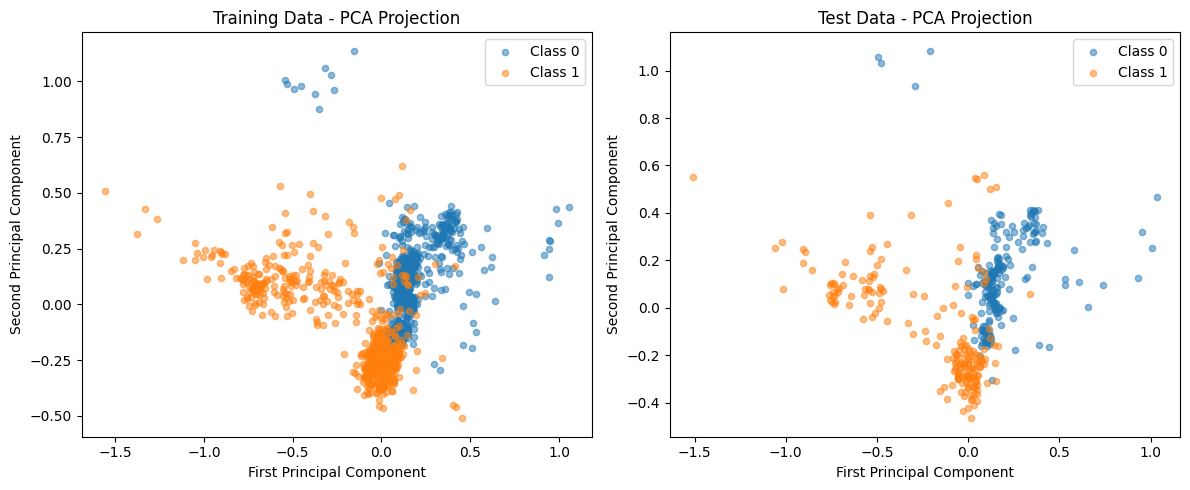


PCA explained variance ratio: [0.28196643 0.16170379]
Total variance explained by 2 components: 0.444

=== Feature Correlation with Target ===

Top 10 features correlated with target:
Q_val            0.567504
signal_mean      0.265651
RR_l_2           0.252749
RR_r_0           0.241035
wr_side          0.241019
RR_l_3           0.215042
RR_l_2/RR_l_3    0.200610
RR_l_0           0.196781
RR_r_1           0.196744
RR_r_2           0.194800
Name: label, dtype: float64

Bottom 10 features:
RR_l_1/RR_l_2    0.081969
P_val           -0.049863
P_pos           -0.230202
T_pos           -0.264685
R_pos           -0.379864
S_pos           -0.417081
Q_pos           -0.420472
wl_side         -0.420640
signal_std      -0.572773
R_val           -0.749451
Name: label, dtype: float64


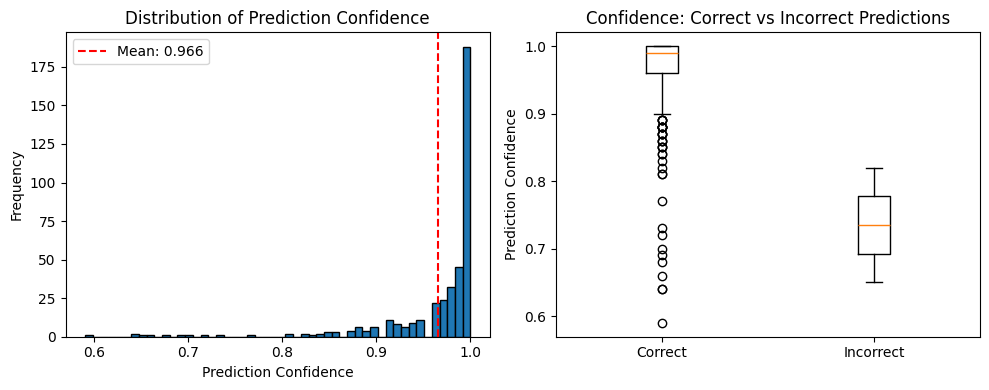


Mean prediction confidence: 0.966
Median prediction confidence: 0.990
Predictions with >0.95 confidence: 311 / 400 (77.8%)


In [12]:
# ============================================================================
# CELL: WHY SUCH HIGH ACCURACY? INVESTIGATION
# ============================================================================

print("=== INVESTIGATING HIGH ACCURACY ===\n")

# 1. Check class balance
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nClass balance: {y_train.value_counts(normalize=True)}")

# 2. Check if classes are easily separable
from sklearn.decomposition import PCA

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.figure(figsize=(12, 5))

# Plot training data
plt.subplot(1, 2, 1)
for label in [0, 1]:
    mask = y_train == label
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                alpha=0.5, label=f'Class {label}', s=20)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Training Data - PCA Projection')
plt.legend()

# Plot test data
plt.subplot(1, 2, 2)
for label in [0, 1]:
    mask = y_test == label
    plt.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], 
                alpha=0.5, label=f'Class {label}', s=20)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Test Data - PCA Projection')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.3f}")

# 3. Check feature correlations with target
print("\n=== Feature Correlation with Target ===")
temp_df = pd.concat([X_train, y_train], axis=1)
correlations = temp_df.corr()['label'].drop('label').sort_values(ascending=False)
print("\nTop 10 features correlated with target:")
print(correlations.head(10))
print("\nBottom 10 features:")
print(correlations.tail(10))

# 4. Check prediction confidence
y_pred_proba = best_rf.predict_proba(X_test)
confidence = np.max(y_pred_proba, axis=1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(confidence, bins=50, edgecolor='black')
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence')
plt.axvline(confidence.mean(), color='red', linestyle='--', label=f'Mean: {confidence.mean():.3f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([confidence[y_pred == y_test], confidence[y_pred != y_test]], 
            labels=['Correct', 'Incorrect'])
plt.ylabel('Prediction Confidence')
plt.title('Confidence: Correct vs Incorrect Predictions')
plt.tight_layout()
plt.show()

print(f"\nMean prediction confidence: {confidence.mean():.3f}")
print(f"Median prediction confidence: {np.median(confidence):.3f}")
print(f"Predictions with >0.95 confidence: {(confidence > 0.95).sum()} / {len(confidence)} ({(confidence > 0.95).mean()*100:.1f}%)")

=== WHY ALL FEATURES > SELECTED 6 FEATURES? ===

Performance Comparison:

All Features:
  Accuracy:  0.9950
  Precision: 0.9950
  Recall:    0.9950
  F1-Score:  0.9950

Selected 6 Features:
  Accuracy:  0.9600
  Precision: 0.9612
  Recall:    0.9600
  F1-Score:  0.9600

=== Feature Importance Analysis ===

Top 15 most important features:
        feature  importance
23        R_val    0.226283
18   signal_std    0.177058
22        Q_val    0.098818
19      wl_side    0.086666
27        Q_pos    0.052335
29        S_pos    0.050198
26        P_pos    0.040530
16     seq_size    0.035883
25        T_val    0.034746
30        T_pos    0.034273
28        R_pos    0.033867
20      wr_side    0.017823
8        RR_r_0    0.016406
17  signal_mean    0.013724
24        S_val    0.011426

Selected 6 features ranking:
  RR_l_0: Rank 1, Importance: 0.0020
  RR_l_0/RR_l_1: Rank 2, Importance: 0.0022
  RR_r_0: Rank 9, Importance: 0.0164
  R_val: Rank 24, Importance: 0.2263
  P_val: Rank 22, Importanc

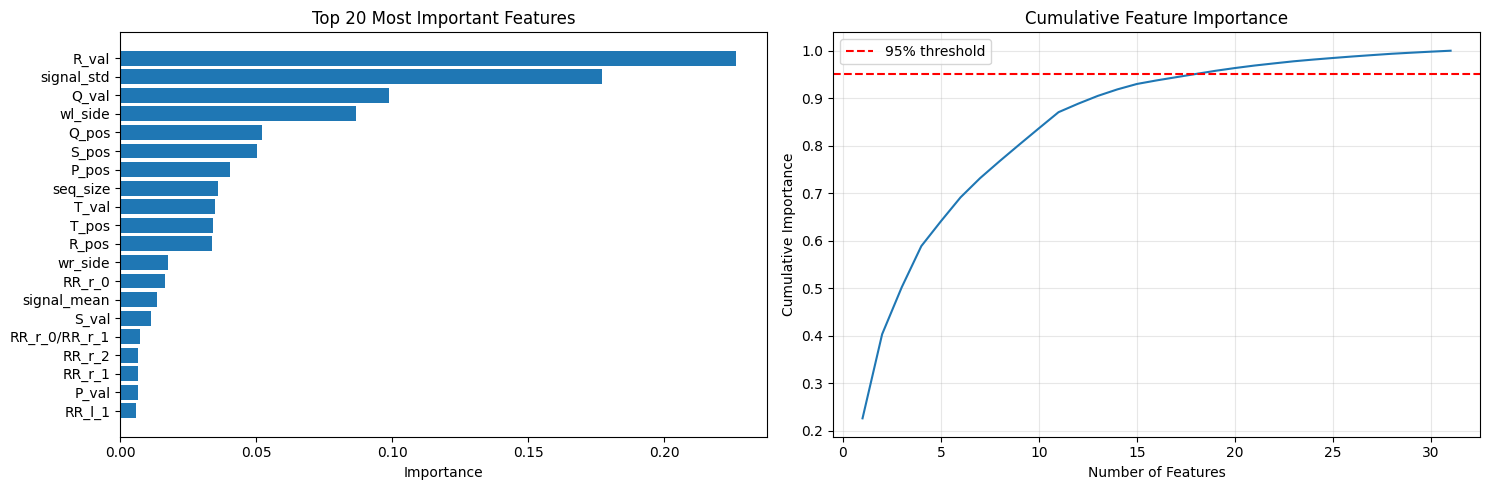


Number of features needed for 95% importance: 18 / 31


In [13]:
# ============================================================================
# CELL: COMPARISON - SELECTED FEATURES vs ALL FEATURES
# ============================================================================

print("=== WHY ALL FEATURES > SELECTED 6 FEATURES? ===\n")

# Train RF on selected features for comparison
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train[FEATURES], y_train)

# Get predictions
y_pred_all = best_rf.predict(X_test)
y_pred_selected = rf_selected.predict(X_test[FEATURES])

# Compare metrics
from sklearn.metrics import precision_score, recall_score, f1_score

print("Performance Comparison:")
print("\nAll Features:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_all):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_all, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_all, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_all, average='weighted'):.4f}")

print("\nSelected 6 Features:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_selected):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_selected, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_selected, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_selected, average='weighted'):.4f}")

# Feature importance analysis
print("\n=== Feature Importance Analysis ===")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(feature_importance.head(15))

# Check if selected features are in top features
print(f"\nSelected 6 features ranking:")
for feat in FEATURES:
    rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
    importance = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    print(f"  {feat}: Rank {rank}, Importance: {importance:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Top 20 features
top_20 = feature_importance.head(20)
axes[0].barh(range(len(top_20)), top_20['importance'])
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Most Important Features')

# Plot 2: Cumulative importance
cumulative_importance = np.cumsum(feature_importance['importance'].values)
axes[1].plot(range(1, len(cumulative_importance)+1), cumulative_importance)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# How many features needed for 95% importance?
n_features_95 = np.argmax(cumulative_importance >= 0.95) + 1
print(f"\nNumber of features needed for 95% importance: {n_features_95} / {len(feature_cols)}")

=== TESTING ON ADDITIONAL 1000 SAMPLES ===

Loaded 800 samples for additional testing

=== Results on 1000-sample test set ===
Accuracy:  0.9975
Precision: 0.9975
Recall:    0.9975
F1-Score:  0.9975

Confusion Matrix:
[[400   0]
 [  2 398]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      0.99      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


=== Comparison: 200-sample vs 1000-sample test sets ===
   Metric  Test 200  Test 1000  Difference
 Accuracy   0.99500   0.997500    0.002500
Precision   0.99505   0.997512    0.002463
   Recall   0.99500   0.997500    0.002500
 F1-Score   0.99500   0.997500    0.002500


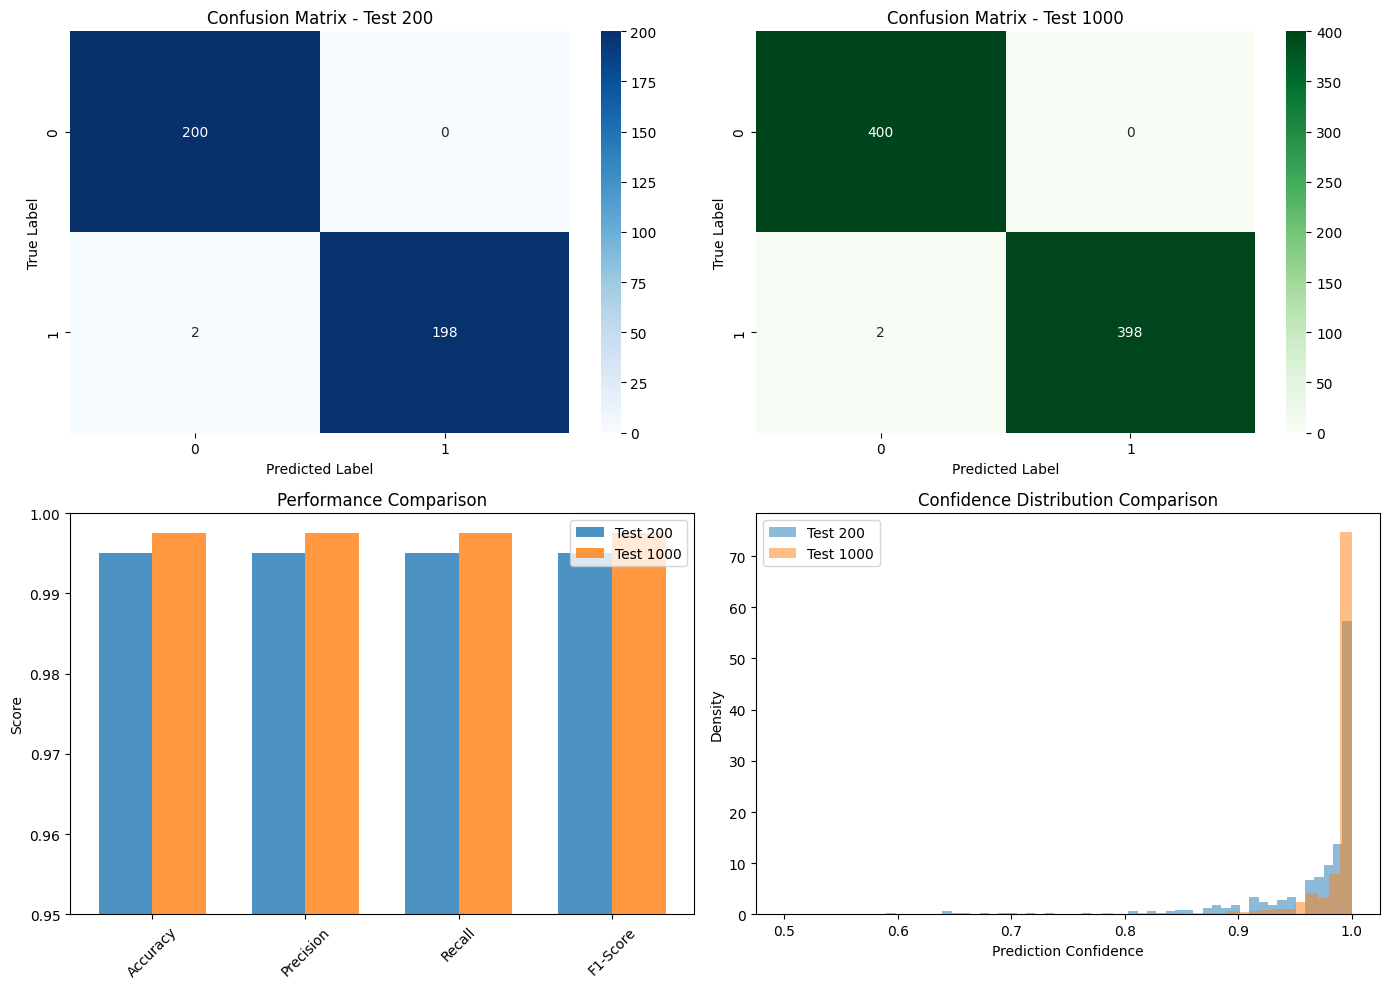


=== Misclassification Analysis (1000 samples) ===
Misclassified: 2 / 800 (0.25%)

Misclassified samples statistics:
         RR_l_0  RR_l_0/RR_l_1    RR_l_1  RR_l_1/RR_l_2    RR_l_2  \
count  2.000000       2.000000  2.000000       2.000000  2.000000   
mean   0.067996       0.203630  0.053371       0.183324  0.051317   
std    0.075647       0.034251  0.052967       0.010396  0.057159   
min    0.014506       0.179411  0.015918       0.175973  0.010899   
25%    0.041251       0.191520  0.034644       0.179648  0.031108   
50%    0.067996       0.203630  0.053371       0.183324  0.051317   
75%    0.094742       0.215740  0.072097       0.186999  0.071526   
max    0.121487       0.227850  0.090824       0.190675  0.091735   

       RR_l_2/RR_l_3    RR_l_3  RR_l_3/RR_l_4    RR_r_0  RR_r_0/RR_r_1  ...  \
count       2.000000  2.000000       2.000000  2.000000       2.000000  ...   
mean        0.192274  0.046776       0.310346  0.070784       0.111592  ...   
std         0.007752  0.

In [14]:
# ============================================================================
# CELL: LOAD AND TEST ON ADDITIONAL 1000 SAMPLES
# ============================================================================

print("=== TESTING ON ADDITIONAL 1000 SAMPLES ===\n")

# Load the additional test set
try:
    test_1000_df = pd.read_csv("tsne_data/test_1000.csv")
    print(f"Loaded {len(test_1000_df)} samples for additional testing")
    
    X_test_1000 = test_1000_df[feature_cols]
    y_test_1000 = test_1000_df["label"]
    
    # Test the model
    y_pred_1000 = best_rf.predict(X_test_1000)
    y_pred_proba_1000 = best_rf.predict_proba(X_test_1000)
    
    # Calculate metrics
    print("\n=== Results on 1000-sample test set ===")
    print(f"Accuracy:  {accuracy_score(y_test_1000, y_pred_1000):.4f}")
    print(f"Precision: {precision_score(y_test_1000, y_pred_1000, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_test_1000, y_pred_1000, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_test_1000, y_pred_1000, average='weighted'):.4f}")
    
    print("\nConfusion Matrix:")
    cm_1000 = confusion_matrix(y_test_1000, y_pred_1000)
    print(cm_1000)
    
    print("\nClassification Report:")
    print(classification_report(y_test_1000, y_pred_1000))
    
    # Compare with original test set
    print("\n=== Comparison: 200-sample vs 1000-sample test sets ===")
    comparison_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Test 200': [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, average='weighted'),
            recall_score(y_test, y_pred, average='weighted'),
            f1_score(y_test, y_pred, average='weighted')
        ],
        'Test 1000': [
            accuracy_score(y_test_1000, y_pred_1000),
            precision_score(y_test_1000, y_pred_1000, average='weighted'),
            recall_score(y_test_1000, y_pred_1000, average='weighted'),
            f1_score(y_test_1000, y_pred_1000, average='weighted')
        ]
    })
    comparison_df['Difference'] = comparison_df['Test 1000'] - comparison_df['Test 200']
    print(comparison_df.to_string(index=False))
    
    # Visualize comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Confusion matrices side by side
    import seaborn as sns
    
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
                cmap='Blues', ax=axes[0, 0])
    axes[0, 0].set_title('Confusion Matrix - Test 200')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')
    
    sns.heatmap(cm_1000, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix - Test 1000')
    axes[0, 1].set_ylabel('True Label')
    axes[0, 1].set_xlabel('Predicted Label')
    
    # 2. Metrics comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    x = np.arange(len(metrics))
    width = 0.35
    
    axes[1, 0].bar(x - width/2, comparison_df['Test 200'], width, label='Test 200', alpha=0.8)
    axes[1, 0].bar(x + width/2, comparison_df['Test 1000'], width, label='Test 1000', alpha=0.8)
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Performance Comparison')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics, rotation=45)
    axes[1, 0].legend()
    axes[1, 0].set_ylim([0.95, 1.0])
    
    # 3. Confidence distribution comparison
    confidence_200 = np.max(y_pred_proba, axis=1)
    confidence_1000 = np.max(y_pred_proba_1000, axis=1)
    
    axes[1, 1].hist(confidence_200, bins=50, alpha=0.5, label='Test 200', density=True)
    axes[1, 1].hist(confidence_1000, bins=50, alpha=0.5, label='Test 1000', density=True)
    axes[1, 1].set_xlabel('Prediction Confidence')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].set_title('Confidence Distribution Comparison')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Misclassification analysis for 1000 samples
    print("\n=== Misclassification Analysis (1000 samples) ===")
    misclassified_1000 = y_test_1000 != y_pred_1000
    print(f"Misclassified: {misclassified_1000.sum()} / {len(y_test_1000)} ({misclassified_1000.sum()/len(y_test_1000)*100:.2f}%)")
    
    if misclassified_1000.sum() > 0:
        print("\nMisclassified samples statistics:")
        print(X_test_1000[misclassified_1000].describe())
        
        print("\nPrediction confidence for misclassified samples:")
        confidence_misclass = np.max(y_pred_proba_1000[misclassified_1000], axis=1)
        print(f"  Mean: {confidence_misclass.mean():.3f}")
        print(f"  Median: {np.median(confidence_misclass):.3f}")
        print(f"  Min: {confidence_misclass.min():.3f}")
        print(f"  Max: {confidence_misclass.max():.3f}")
    
except FileNotFoundError:
    print("Error: test_1000.csv not found!")
    print("Please run: python prepare_additional_test.py sampled_tsne_prepared.csv")
except Exception as e:
    print(f"Error loading or processing 1000-sample test set: {e}")